=== Linear Model Coefficients ===
      Feature  Coefficient
    Intercept      17.4253
   Experience      -0.9638
TrainingHours       0.0380
 WorkingHours       0.8190
     Projects       4.7014

R^2: 0.9972   Adjusted R^2: 0.995

=== Standardized Coefficients (Effect Size) ===
      Feature  Std_Coefficient (per 1 SD increase)
     Projects                              10.5545
 WorkingHours                               3.5407
   Experience                              -2.6848
TrainingHours                               0.8906

=== VIF (Multicollinearity Check) ===
Experience: 49.54
TrainingHours: 88.56
WorkingHours: 86.07
Projects: 58.89

LOOCV RMSE (Linear): 1.8404

=== Quadratic Model (adds WorkingHours^2) ===
       Feature  Coefficient
     Intercept    -128.6282
    Experience       1.3396
 TrainingHours      -0.0883
  WorkingHours       7.9668
      Projects       2.3954
WorkingHours^2      -0.0817
R^2: 0.9987   Adjusted R^2: 0.997
LOOCV RMSE (Quadratic): 1.7227


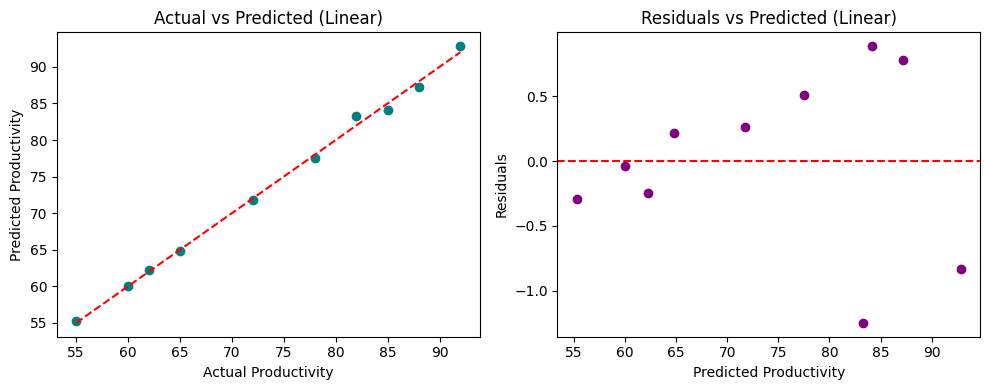

In [ ]:
# --- Setup ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error

# --- Data ---
data = {
    'Experience': [2,5,1,8,4,10,3,6,7,2],
    'TrainingHours': [40,60,20,80,50,90,30,70,75,25],
    'WorkingHours': [38,42,35,45,40,48,37,44,46,36],
    'Projects': [3,6,2,8,5,9,4,7,7,3],
    'Productivity': [62,78,55,88,72,92,65,82,85,60]
}
df = pd.DataFrame(data)

X_cols = ['Experience','TrainingHours','WorkingHours','Projects']
y_col = 'Productivity'
X = df[X_cols].values
y = df[y_col].values

# --- Fit simple linear regression ---
lin = LinearRegression()
lin.fit(X, y)
y_pred = lin.predict(X)

# R^2 and Adjusted R^2
n, p = X.shape
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - y.mean())**2)
r2 = 1 - ss_res/ss_tot
adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)

# --- Standardized coefficients (effect sizes) ---
scaler = StandardScaler(with_mean=True, with_std=True)
Xz = scaler.fit_transform(X)  # standardize predictors only
lin_z = LinearRegression()
lin_z.fit(Xz, y)
std_coefs = lin_z.coef_  # comparable effect per 1 SD increase

# --- VIF to check multicollinearity ---
# VIF_j = 1 / (1 - R_j^2), where R_j^2 from regressing x_j on other predictors
def compute_vif(X, colnames):
    vif = {}
    for j, name in enumerate(colnames):
        X_other = np.delete(X, j, axis=1)
        xj = X[:, j]
        reg = LinearRegression().fit(X_other, xj)
        r2_j = reg.score(X_other, xj)
        vif[name] = 1.0/(1.0 - r2_j) if r2_j < 1 else np.inf
    return vif

vif = compute_vif(X, X_cols)

# --- Leave-One-Out Cross-Validation (LOOCV) ---
loo = LeaveOneOut()
preds_loo = []
truth_loo = []
for train_idx, test_idx in loo.split(X):
    lin_loo = LinearRegression().fit(X[train_idx], y[train_idx])
    preds_loo.append(lin_loo.predict(X[test_idx])[0])
    truth_loo.append(y[test_idx][0])

loo_mse = mean_squared_error(truth_loo, preds_loo)
loo_rmse = np.sqrt(loo_mse)

# --- Optional: add curvature for WorkingHours (quadratic term) ---
X_quad = np.column_stack([X, X[:, X_cols.index('WorkingHours')]**2])
lin_q = LinearRegression().fit(X_quad, y)
y_pred_q = lin_q.predict(X_quad)
ss_res_q = np.sum((y - y_pred_q)**2)
r2_q = 1 - ss_res_q/ss_tot
adj_r2_q = 1 - (1-r2_q)*(n-1)/(n-(p+1)-1)

# LOOCV for quadratic model
preds_loo_q = []
truth_loo_q = []
for train_idx, test_idx in loo.split(X_quad):
    lin_loo_q = LinearRegression().fit(X_quad[train_idx], y[train_idx])
    preds_loo_q.append(lin_loo_q.predict(X_quad[test_idx])[0])
    truth_loo_q.append(y[test_idx][0])
loo_mse_q = mean_squared_error(truth_loo_q, preds_loo_q)
loo_rmse_q = np.sqrt(loo_mse_q)

# --- Report ---
coef_table = pd.DataFrame({
    'Feature': ['Intercept'] + X_cols,
    'Coefficient': [lin.intercept_] + list(lin.coef_)
})
std_coef_table = pd.DataFrame({
    'Feature': X_cols,
    'Std_Coefficient (per 1 SD increase)': std_coefs
})

quad_table = pd.DataFrame({
    'Feature': ['Intercept'] + X_cols + ['WorkingHours^2'],
    'Coefficient': [lin_q.intercept_] + list(lin_q.coef_)
})

print("=== Linear Model Coefficients ===")
print(coef_table.round(4).to_string(index=False))
print("\nR^2:", round(r2, 4), "  Adjusted R^2:", round(adj_r2, 4))

print("\n=== Standardized Coefficients (Effect Size) ===")
print(std_coef_table.sort_values(by='Std_Coefficient (per 1 SD increase)',
                                 key=lambda s: s.abs(), ascending=False).round(4).to_string(index=False))

print("\n=== VIF (Multicollinearity Check) ===")
for k,v in vif.items():
    print(f"{k}: {v:.2f}")

print("\nLOOCV RMSE (Linear):", round(loo_rmse, 4))

print("\n=== Quadratic Model (adds WorkingHours^2) ===")
print(quad_table.round(4).to_string(index=False))
print("R^2:", round(r2_q, 4), "  Adjusted R^2:", round(adj_r2_q, 4))
print("LOOCV RMSE (Quadratic):", round(loo_rmse_q, 4))

# Simple diagnostic plots
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].scatter(y, y_pred, color='teal')
ax[0].plot([min(y), max(y)], [min(y), max(y)], 'r--')
ax[0].set_title('Actual vs Predicted (Linear)')
ax[0].set_xlabel('Actual Productivity')
ax[0].set_ylabel('Predicted Productivity')

resid = y - y_pred
ax[1].scatter(y_pred, resid, color='purple')
ax[1].axhline(0, color='r', linestyle='--')
ax[1].set_title('Residuals vs Predicted (Linear)')
ax[1].set_xlabel('Predicted Productivity')
ax[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()